In [1]:
import os
import logging
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import mixed_precision
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.metrics as metrics
from sklearn.metrics import roc_curve, auc

2026-05-03 15:16:32.942110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777821393.162652      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777821393.225253      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777821393.754973      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777821393.755013      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777821393.755016      22 computation_placer.cc:177] computation placer alr

In [2]:
# --- 1. GPU & ACCELERATION SETUP ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

# Enable Mixed Precision for T4 GPUs
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Initialize Strategy for 2 GPUs
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

Number of GPUs: 2


I0000 00:00:1777821419.547900      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777821419.554072      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# --- 2. DATA LOADING & PREPARATION ---
dataset_path = "/kaggle/input/datasets/organizations/nih-chest-xrays/data" # Adjust if your path is different
df = pd.read_csv(dataset_path + '/Data_Entry_2017.csv')

# Map Gender to Binary
df['Gender_Label'] = df['Patient Gender'].map({'M': 0, 'F': 1})

# Map image paths
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join(dataset_path, 'images_*', 'images', '*.png'))}
df['path'] = df['Image Index'].map(all_image_paths.get)
df = df.dropna(subset=['path'])

# Patient-wise Split
patient_ids = df['Patient ID'].unique()
train_ids, test_val_ids = train_test_split(patient_ids, test_size=0.20, random_state=42)
val_ids, test_ids = train_test_split(test_val_ids, test_size=0.50, random_state=42)

train_df = df[df['Patient ID'].isin(train_ids)]
valid_df = df[df['Patient ID'].isin(val_ids)]
test_df = df[df['Patient ID'].isin(test_ids)]

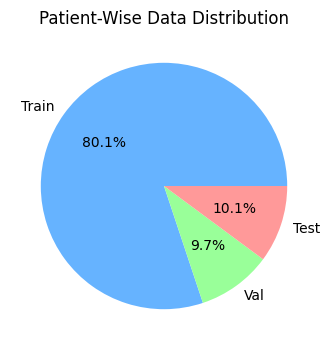

In [4]:
# --- 3. VISUALIZATION 1: DATA SPLIT ---
split_counts = {'Train': len(train_df), 'Val': len(valid_df), 'Test': len(test_df)}
plt.figure(figsize=(6, 4))
plt.pie(split_counts.values(), labels=split_counts.keys(), autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Patient-Wise Data Distribution')
plt.show()

In [5]:
# --- 4. PREPROCESSING FUNCTION ---
def medical_preprocessing(img):
    img = img.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    if len(img.shape) == 2 or img.shape[2] == 1:
        img_clahe = clahe.apply(img if len(img.shape)==2 else img[:,:,0])
        img_final = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    else:
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        lab = cv2.merge((l2, a, b))
        img_final = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return img_final.astype(np.float32) / 255.0

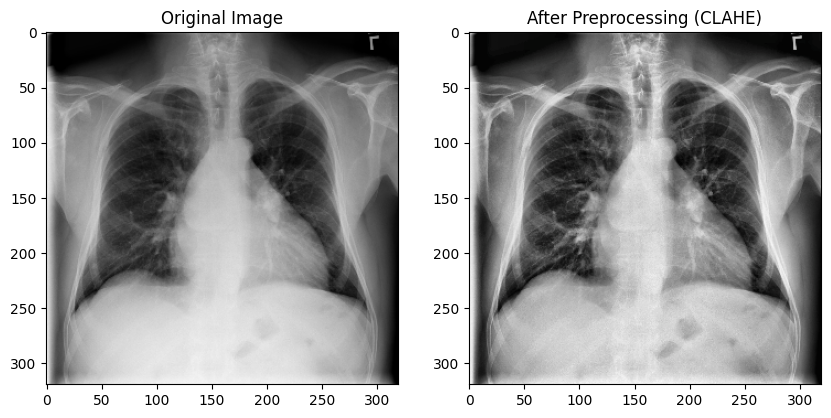

In [6]:
# --- 5. VISUALIZATION 2: PREPROCESSING AUDIT ---
sample_path = train_df.iloc[0]['path']
raw_img = cv2.imread(sample_path)
raw_img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
processed_img = medical_preprocessing(cv2.resize(raw_img_rgb, (320, 320)))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.resize(raw_img_rgb, (320, 320)))
ax[0].set_title("Original Image")
ax[1].imshow(processed_img)
ax[1].set_title("After Preprocessing (CLAHE)")
plt.show()

In [7]:
# --- 6. GENERATORS ---
IMG_SIZE = (320, 320)
BATCH_SIZE = 32 * strategy.num_replicas_in_sync 

train_datagen = ImageDataGenerator(preprocessing_function=medical_preprocessing, 
                                   horizontal_flip=True, rotation_range=5)
test_datagen = ImageDataGenerator(preprocessing_function=medical_preprocessing)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='path', y_col='Gender_Label',
    class_mode='raw', target_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)

valid_gen = test_datagen.flow_from_dataframe(
    dataframe=valid_df, x_col='path', y_col='Gender_Label',
    class_mode='raw', target_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='path', y_col='Gender_Label',
    class_mode='raw', target_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

Found 89826 validated image filenames.
Found 10930 validated image filenames.
Found 11364 validated image filenames.


In [8]:
# --- 7. MODEL BUILDING (IMPROVED) ---
def build_gender_model():
    with strategy.scope():
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
        
        # Performance Boost: Unfreeze the last block of DenseNet
        # This allows the model to learn the specific textures of chest anatomy
        base_model.trainable = True
        for layer in base_model.layers[:-30]:
            layer.trainable = False

        x = GlobalAveragePooling2D()(base_model.output)
        x = Dropout(0.3)(x)
        predictions = Dense(1, activation='sigmoid', dtype='float32')(x)
        
        model = Model(inputs=base_model.input, outputs=predictions)
        model.compile(
            optimizer=Adam(learning_rate=1e-4), # Lower LR for fine-tuning
            loss='binary_crossentropy',
            metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.AUC(name='auc')]
        )
    return model

model = build_gender_model()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# --- 8. TRAINING ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_gender_model.keras', monitor='val_auc', mode='max', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]

# We use the full dataset per epoch to break the 0.54 accuracy plateau
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=valid_gen,
    steps_per_epoch=len(train_gen), # IMPORTANT: Use full data
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1777821717.912874      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777821717.912895      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4464s 3s/step - accuracy: 0.8547 - auc: 0.9286 - loss: 0.3105 - val_accuracy: 0.9545 - val_auc: 0.9924 - val_loss: 0.1146 - learning_rate: 1.0000e-04
Epoch 2/10
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4365s 3s/step - accuracy: 0.9503 - auc: 0.9903 - loss: 0.1240 - val_accuracy: 0.9623 - val_auc: 0.9936 - val_loss: 0.0972 - learning_rate: 1.0000e-04
Epoch 3/10
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4266s 3s/step - accuracy: 0.9629 - auc: 0.9942 - loss: 0.0941 - val_accuracy: 0.9582 - val_auc: 0.9936 - val_loss: 0.1129 - learning_rate: 1.0000e-04
Epoch 4/10
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4289s 3s/step - accuracy: 0.9686 - auc: 0.9958 - loss: 0.0801 - val_accuracy: 0.9645 - val_auc: 0.9951 - val_loss: 0.0881 - learning_rate: 1.0000e-04
Epoch 5/10
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4270s 3s/step - accuracy: 0.9737 - auc: 0.9965 - loss: 0.0712 - val_accuracy: 0.9687 - val_auc: 0.9956 - val_loss: 0.0820 - learning_rate: 1.0000e-04
Epoch 6/10
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4119s 3s/

178/178 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step


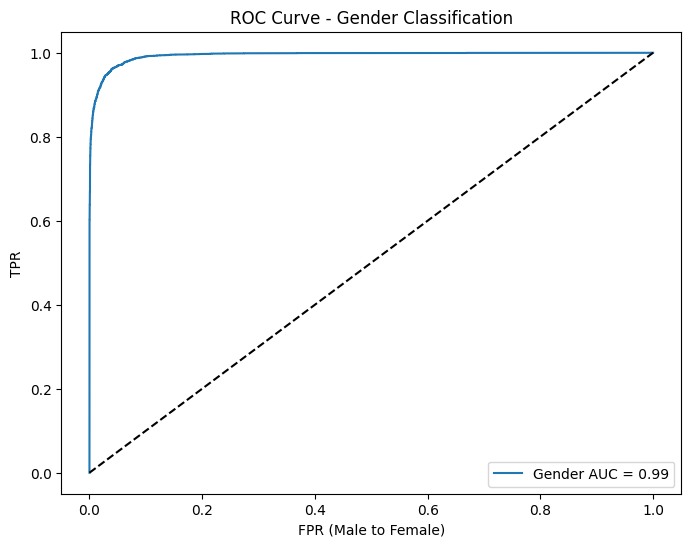

In [10]:
# --- 9. FINAL ROC EVALUATION ---
test_gen.reset()
predictions = model.predict(test_gen, steps=len(test_gen), verbose=1)
fpr, tpr, _ = roc_curve(test_df['Gender_Label'], predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Gender AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR (Male to Female)')
plt.ylabel('TPR')
plt.title('ROC Curve - Gender Classification')
plt.legend()
plt.show()